# Bootcamp: From Data to Prediction - Supervised Learning Path
## Hari 2: Exploratory Data Analysis (EDA) & Data Preprocessing
Selamat datang di Fase Detektif Data! Hari ini kita tidak hanya menulis kode, melainkan belajar mendiagnosis kesehatan data mentah, membersihkan anomali, dan meracik grafik visual untuk memecahkan misteri bisnis.

###  Peta Perjalanan Kita Hari Ini:
1. **Data Ingestion & Profiling:** Memuat data dan mengaudit anatomi serta dimensinya.
2. **Data Cleaning:** Strategi menambal lubang informasi (*Missing Values*).
3. **Feature Engineering & Transformation:** Meracik fitur baru dan mengubah teks menjadi angka.
4. **Univariate Analysis:** Membedah karakteristik variabel secara mandiri.
5. **Bivariate & Multivariate Analysis:** Mengawinkan antar variabel untuk mencari korelasi sebab-akibat.
6. **Distribution Analysis & Deteksi Anomali**
: Melihat distribusi kolom dan melihat data anomali

7. **Correlation Matrix:** Membaca peta hubungan makro seluruh data.

Mari kita siapkan peralatan tempur kita!

In [7]:
# Import library wajib untuk Data Science dan Visualisasi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visual standar agar grafik rapi dan seragam
sns.set_theme(style="whitegrid")
print("Library berhasil dimuat dan siap digunakan!")

Library berhasil dimuat dan siap digunakan!


## TAHAP 1: Data Profiling
Sebelum melakukan tindakan apa pun, seorang Data Scientist wajib melakukan audit struktur data. Tahap ini bertujuan untuk mengetahui **Dimensi Data** (berapa jumlah baris populasi dan kolom yang tersedia) serta melihat **Taksonomi Tipe Data** (apakah kolom tersebut berisi angka kontinu atau teks kategorikal).

In [8]:
# memuat data dan melihat dimensi tabel
url_data = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
# Tulis kode Anda di bawah ini:


print(f"Total Baris :  {pd.read_csv(url_data).shape[0]}")
print(f"Total Kolom :  {pd.read_csv(url_data).shape[1]}")


Total Baris :  891
Total Kolom :  12


In [9]:
# [PRAKTIK & ANALISIS]
# 1. Panggil dataset ke variabel 'df'
# KETIK DI SINI:
df = pd.read_csv(url_data)

# 2. Cek kolom apa saja yang memiliki nilai kosong (missing values) dan berapa jumlahnya!
# KETIK DI SINI (Gunakan isnull dan sum):
print("Hasil audit data kosong : ")
print(df.isnull().sum())

# TULIS KESIMPULANMU DI BAWAH INI (Jadikan comment):
# Kolom yang bolong adalah: Age, Cabin, Embarked

Hasil audit data kosong : 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Teknik Alternatif: Ringkasan Statistik via `.describe()`
Selain melihat dimensi, kita bisa memprofiling nilai pusat data menggunakan fungsi `.describe()`. Secara default fungsi ini hanya membaca kolom angka, namun kita bisa memaksanya membaca kolom teks menggunakan parameter `include='object'`.

In [10]:
# Melihat karakteristik khusus data berbasis teks/kategori
display(df.describe(include='object')) # all, object

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


---
## TAHAP 2: Data Cleaning (Drop vs Imputation)
Ada dua mazhab mengatasi data kosong:
1. **Dihapus (.dropna):** Cepat, tapi berisiko kehilangan banyak informasi. Cocok jika yang bolong hanya 1-2 baris.
2. **Ditambal (.fillna):** Mengisi dengan nilai statistik (Rata-rata/Mean, Nilai Tengah/Median, atau Modus/Nilai paling sering muncul).

Untuk kolom `Age` (Umur) yang bolong 177 data, kita akan tambal pakai rata-rata.

In [11]:
# CONTOH 1: Menghapus baris (Tidak disarankan untuk kasus Umur ini)
df_buang = df.dropna(subset=['Age']) #menghapus data dimana field Age bernilai null
df_buang.info()

# CONTOH 2: Menambal dengan Rata-rata (Mean Imputation)
rata_rata_umur = df["Age"].mean()
print(f"Nilai rata-rata (mean Age) : {rata_rata_umur:.2f} tahun")

#eksekusi imputation
df["Age"] = df['Age'].fillna(rata_rata_umur)
print("Jumlah data kosong di dalam kolom Age sekarang :", df['Age'].isnull().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    object 
 4   Sex          714 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    object 
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    object 
 11  Embarked     712 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.5+ KB
Nilai rata-rata (mean Age) : 29.70 tahun
Jumlah data kosong di dalam kolom Age sekarang : 0


### 💡 Teknik Alternatif: Median Imputation
Jika sebaran data angka Anda memiliki pencilan (*outliers*) yang sangat ekstrem, menggunakan nilai rata-rata (*mean*) menjadi tidak akurat karena nilainya akan tertarik oleh angka ekstrem tersebut. Solusi teoretis yang lebih aman adalah menggunakan **Median** (Nilai Tengah).

In [12]:
# Contoh melihat nilai tengah sebagai alternatif penambalan
nilai_tengah_umur = df['Age'].median()
print(f'Nilai alternatif dari mean age adalah median Age : {nilai_tengah_umur:.2f}')

Nilai alternatif dari mean age adalah median Age : 29.70


In [13]:
# [PRAKTIK & ANALISIS]
# Coba perhatikan kolom 'Embarked' (Pelabuhan). Ada 2 data yang bolong!
# Karena 'Embarked' adalah data TEKS (bukan angka), kita tidak bisa pakai rata-rata.
# Kita harus tambal dengan Modus (Nilai yang paling sering muncul).
print("Value dari data pelabuhan sekarang adalah :")
print(df['Embarked'].value_counts())

# 1. Cari tahu pelabuhan mana yang paling banyak penumpangnya
# KETIK DI SINI
embarked_modus = df['Embarked'].mode()[0]
print("Pelabuhan yang paling banyak penumpangnya (modus embarked) adalah :", embarked_modus)

# 2. Tambal data bolong di 'Embarked' dengan pelabuhan terbanyak tersebut!
# KETIK DI SINI
df['Embarked'] = df['Embarked'].fillna(embarked_modus)
print("======"*15)
print("Maka tambal data yang bolong. Value dari data pelabuhan setelah ditambal adalah : ")
print(df['Embarked'].value_counts())
print("Jumlah data kosong didalam kolom Embarked sekarang: ", df['Embarked'].isnull().sum())


# TULIS KESIMPULANMU:
# Kenapa data teks tidak bisa ditambal pakai .mean() ?
# Jawab: Data teks (kategorikal) tidak memiliki nilai numerik yang dapat dihitung rata-ratanya. Fungsi mean() hanya berlaku untuk data numerik.

Value dari data pelabuhan sekarang adalah :
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Pelabuhan yang paling banyak penumpangnya (modus embarked) adalah : S
Maka tambal data yang bolong. Value dari data pelabuhan setelah ditambal adalah : 
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Jumlah data kosong didalam kolom Embarked sekarang:  0


### TAHAP 3: Modifikasi Fitur (Persiapan Machine Learning)
Algoritma matematika kecerdasan buatan memiliki hukum besi: **Hanya bisa membaca angka, tidak bisa membaca teks**. Oleh karena itu, kita harus melakukan *Data Transformation* untuk mengubah teks menjadi representasi angka.

Selain itu, kita bisa melakukan *Feature Engineering*, yaitu menggabungkan beberapa kolom bernilai kecil untuk menciptakan satu kolom baru yang memiliki makna informasi lebih kuat.

In [14]:
# Feature Engineering: Membuat kolom 'Family_Size' (Ukuran Keluarga)
# Menggabungkan kolom SibSp (saudara) + Parch (orang tua/anak) + 1 (diri sendiri)

df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
display(df[['Name', 'SibSp', 'Parch', 'Family_Size' ]].sample(3))

,Name,SibSp,Parch,Family_Size
246,"Lindahl, Miss. Agda Thorilda Viktoria",0,0,1
114,"Attalah, Miss. Malake",0,0,1
34,"Meyer, Mr. Edgar Joseph",1,0,2


### 💡 Teknik Alternatif: Transformasi Nilai via `.map()`
Untuk mengubah kolom teks berisi dua kategori (seperti `Sex`: male, female) menjadi angka binary (0 dan 1), kita bisa menggunakan fungsi pencocokan kamus berupa metode `.map()`.

In [15]:
# Mengubah teks gender menjadi kode angka binary
df['Sex_Numeric'] = df['Sex'].map({'male': 0, 'female': 1})
display(df[['Name', 'Sex', 'Sex_Numeric']].sample(3))

,Name,Sex,Sex_Numeric
866,"Duran y More, Miss. Asuncion",female,1
541,"Andersson, Miss. Ingeborg Constanzia",female,1
263,"Harrison, Mr. William",male,0


---
### 🚨 KUIS MANDIRI - Transformasi Multi-Kategori ke Angka
**Studi Kasus:** Kolom `Embarked` berisi tiga teks pelabuhan: 'S', 'C', dan 'Q'.
**Tugas Anda:** Lakukan transformasi data pada kolom `Embarked` tersebut menggunakan teknik pencocokan kamus (`.map()`) agar nilainya berubah menjadi angka dengan ketentuan:
* 'S' berubah menjadi angka `0`
* 'C' berubah menjadi angka `1`
* 'Q' berubah menjadi angka `2`

In [16]:
# Lakukan transformasi kolom 'Embarked' menjadi numerik di bawah ini:
df['Embarked_Numeric'] = df['Embarked'].map({'S':0, 'C': 1, 'Q': 2})
display(df[['Name', 'Embarked', 'Embarked_Numeric']].tail(3))


,Name,Embarked,Embarked_Numeric
888,"Johnston, Miss. Catherine Helen ""Carrie""",S,0
889,"Behr, Mr. Karl Howell",C,1
890,"Dooley, Mr. Patrick",Q,2


---
## TAHAP 4: Univariate Analysis
Univariate Analysis adalah proses membedah karakteristik satu kolom secara terisolasi. Sesuai aturan taksonomi grafik, jika variabel yang ingin kita amati berbentuk **Kategorikal (Grup/Teks)**, maka jenis senjata visual terbaik untuk menghitung jumlah frekuensinya adalah **Diagram Batang (Bar Chart / Countplot)**.

Kita akan memvisualisasikan satu kolom untuk melihat distribusinya. Untuk data kategori (teks/grup), kita gunakan **Bar Chart / Countplot**.



* **Cara Pandas:** `df['Kolom'].value_counts().plot(kind='bar')`
* **Cara Seaborn (Lebih Cantik):** `sns.countplot(x='Kolom', data=df)`

/tmp/ipykernel_527/3363603371.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2')


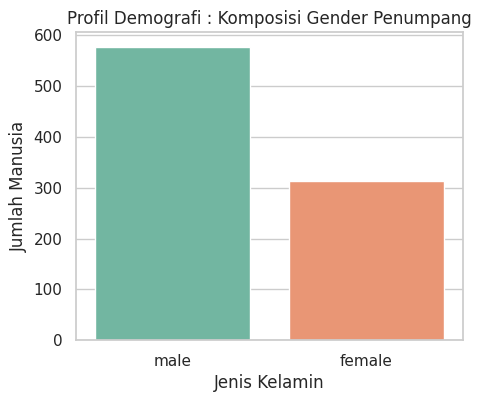

In [17]:
# Visualisasi Jumlah Penumpang Pria vs Wanita
plt.figure(figsize=(5, 4))
sns.countplot(x='Sex', data=df, palette='Set2')

plt.title('Profil Demografi : Komposisi Gender Penumpang', fontsize=12)
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Manusia')
plt.show()

# Insight: Jumlah penumpang pria jauh lebih banyak daripada perempuan

/tmp/ipykernel_527/2418193385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Blues')


<function matplotlib.pyplot.show(close=None, block=None)>

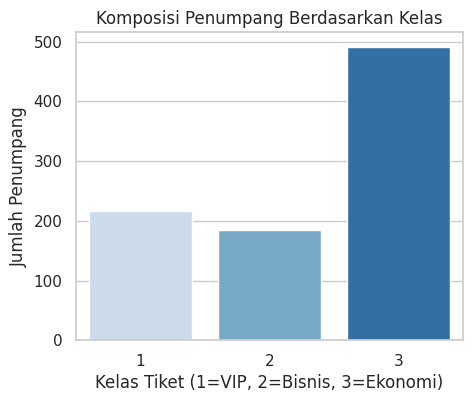

In [18]:
# [PRAKTIK & ANALISIS]
# Buatlah Countplot untuk melihat komposisi Kelas Tiket ('Pclass')!
plt.figure(figsize=(5, 4))

# KETIK DI SINI:
sns.countplot(x='Pclass', data=df, palette='Blues')

plt.title('Komposisi Penumpang Berdasarkan Kelas')
plt.xlabel('Kelas Tiket (1=VIP, 2=Bisnis, 3=Ekonomi)')
plt.ylabel('Jumlah Penumpang')
plt.show

# TULIS KESIMPULANMU:
# Kelas tiket mana yang paling banyak penumpangnya? Kenapa logis?
# Jawab: Kelas tiket yang paling banyak penumpangnya adalah kelas 3, logis karena ekonomi adalah kelas dengan harga paling murah sehingga demand lebih banyak, kelas VIP dan bisnis memiliki tiket khusus atau jauh lebih mahal

### 💡 Teknik Alternatif: Visualisasi Langsung via Pandas Plotting
Selain memanggil library Seaborn, Pandas sebenarnya memiliki fungsi visualisasi bawaan yang memanfaatkan mesin Matplotlib di belakangnya. Keuntungannya adalah eksekusi kodenya jauh lebih pendek.

<function matplotlib.pyplot.show(close=None, block=None)>

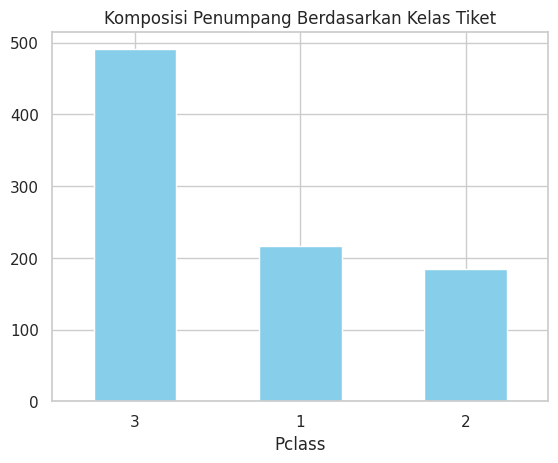

In [19]:
# Menggambar grafik batang menggunakan fungsi internal Pandas DataFrame
df['Pclass'].value_counts().plot(kind='bar', color='skyblue', rot=0)
plt.title('Komposisi Penumpang Berdasarkan Kelas Tiket')
plt.show
# Sama seperti sebelumnya, karena kelas tiket 3 paling murah maka logis bila pembelinya alias penumpangnya adalah yang terbanyak

---
## TAHAP 5: Bivariate Analysis (Sebab-Akibat)

Bivariate Analysis digunakan untuk menguji interaksi dan mencari benang merah sebab-akibat antara dua variabel. Kita akan menggunakan fungsi `sns.barplot()`. Uniknya, jika variabel pada sumbu Y berupa data binary berangka `0` (Meninggal) dan `1` (Selamat), Seaborn akan secara otomatis menghitung nilai **Peluang Keberhasilan / Rata-rata Survival Rate** kelompok tersebut. Kita juga bisa menambah dimensi ketiga dengan parameter `hue`.

/tmp/ipykernel_527/436645928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_r', errorbar=None)


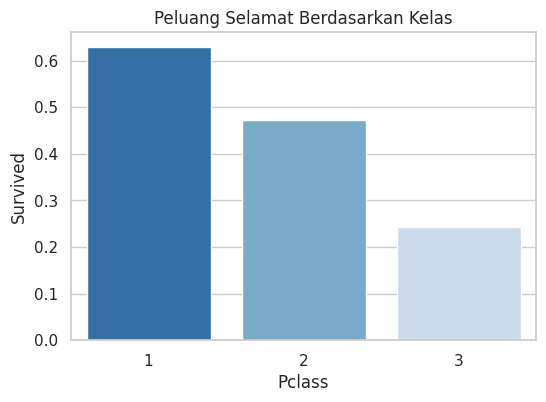

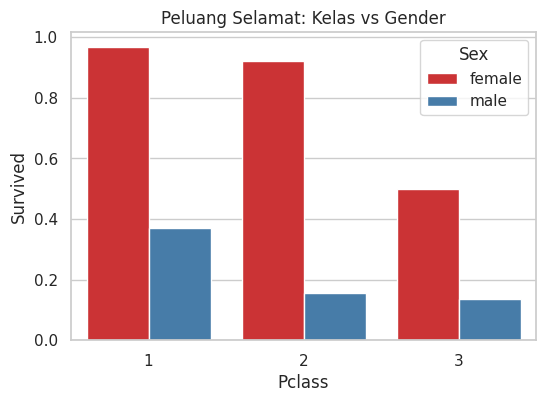

In [20]:
# Analisis Dasar: Kelas Tiket vs Peluang Selamat
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_r', errorbar=None)
plt.title('Peluang Selamat Berdasarkan Kelas')
plt.show()
# Logis karena kelas VIP biasanya di tempatkan di kamar paling atas kapal, mendapat perlakuan fasilitas khusus, dan kmeungkinan memiliki sekoci pribadi

# Analisis Advanced (Menggunakan Parameter HUE)
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y ='Survived', hue='Sex', data=df, palette='Set1', errorbar=None)
plt.title('Peluang Selamat: Kelas vs Gender')
plt.show()
# Logis karena perempuan dan anak2 biasanya di dahulukan dalam evakuasi dan keadaan darurat kecelakaan

# Insight:

/tmp/ipykernel_527/1358428816.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Fare', data=df, palette='autumn', errorbar=None)


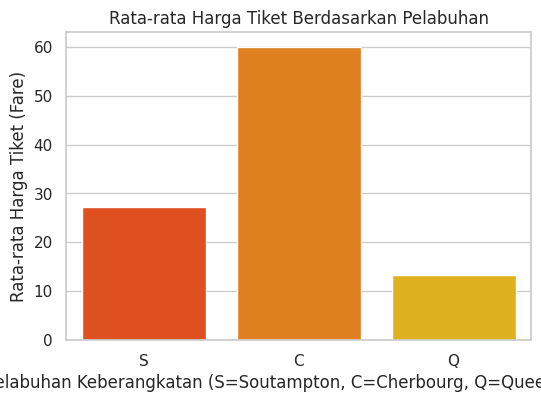

In [21]:
# [PRAKTIK & ANALISIS]
# Bos ingin tahu: Pelabuhan mana ('Embarked') yang rata-rata penumpangnya bayar tiket paling mahal ('Fare')?
# Buatlah barplot dengan x='Embarked' dan y='Fare' !

# Membuat barplot untuk membandingkan rata-rata harga tiket (Fare) di tiap pelabuhan (Embarked)
# errorbar=None digunakan agar tidak memunculkan garis ketidakpastian (ci) sehingga grafik lebih bersih bagi pemula
plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Fare', data=df, palette='autumn', errorbar=None)

# KETIK DI SINI:
plt.title("Rata-rata Harga Tiket Berdasarkan Pelabuhan")
plt.xlabel("Pelabuhan Keberangkatan (S=Soutampton, C=Cherbourg, Q=Queenstown)")
plt.ylabel("Rata-rata Harga Tiket (Fare)")
plt.show()

# TULIS KESIMPULANMU:
# Pelabuhan mana yang merupakan tempat naiknya para "Sultan" (VIP)?
# Jawab: Pelabuhan C=Cherbourge, logis karena sultan membeli harga tiket yang paling tinggi atau mahal, maka mereka berada di pelabuhan tersebut

---
## TAHAP 6: Distribution Analysis & Deteksi Anomali
Untuk melihat sebaran data angka (numerik), kita punya dua senjata:
1. **Histogram (`sns.histplot`):** Melihat kepadatan data (seperti gunung).
2. **Boxplot (`sns.boxplot`):** Sangat ampuh untuk melihat *Outliers* (Pencilan/Nilai abnormal).

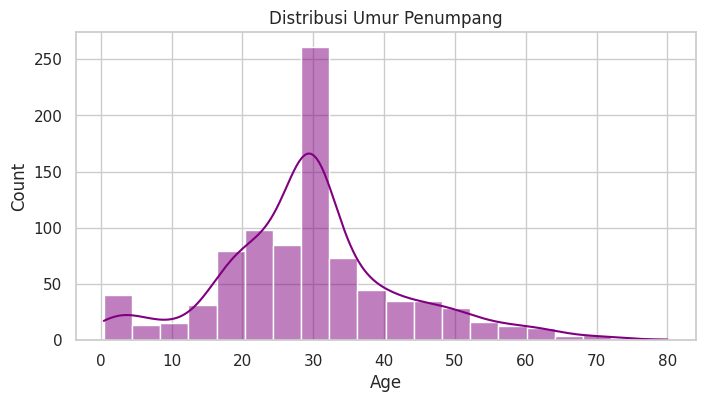

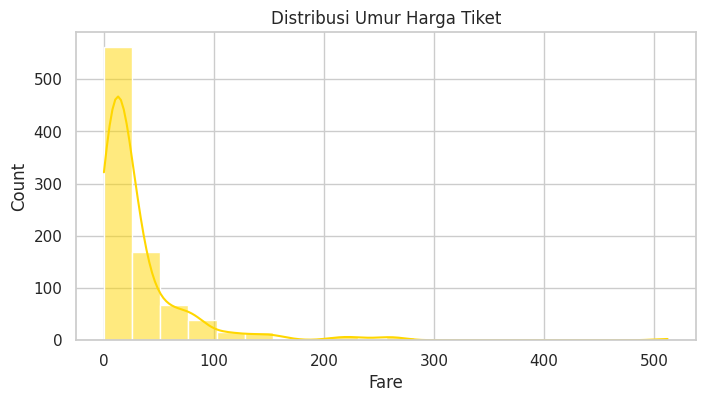

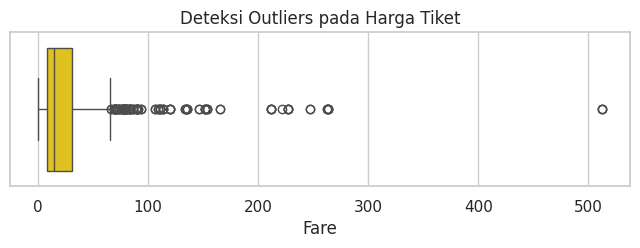

In [22]:
# 1. Histogram (Sebaran Umur)
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, color='purple', bins=20)
plt.title('Distribusi Umur Penumpang')
plt.show()

print("========" * 12)
print("========" * 12)

plt.figure(figsize=(8,4))
sns.histplot(df['Fare'], kde=True, color='gold', bins=20)
plt.title('Distribusi Umur Harga Tiket')
plt.show()

# 2. Boxplot (Mendeteksi Anomali Harga Tiket)

print("========" * 12)
print("========" * 12)

plt.figure(figsize=(8,2))
sns.boxplot(x=df['Fare'], color='gold')
plt.title('Deteksi Outliers pada Harga Tiket')
plt.show()



# Insight: Ada titik-titik hitam jauh di kanan pada Boxplot. Itu adalah penumpang yang bayar tiket di atas 500 dollar (Anomali/Outlier)!


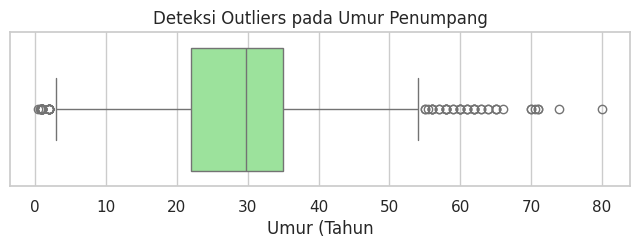

In [23]:
# [PRAKTIK & ANALISIS]
# Buatlah Boxplot untuk melihat apakah ada OUTLIERS pada umur penumpang ('Age')!
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['Age'], color='lightgreen')

# KETIK DI SINI:
plt.title('Deteksi Outliers pada Umur Penumpang')
plt.xlabel('Umur (Tahun')
plt.show()

# TULIS KESIMPULANMU:
# Apakah ada titik hitam (outliers) di sebelah kanan boxplot? Kira-kira umur berapa itu?
# Jawab: ....................

## TAHAP 7:  Matriks Korelasi Pearson
Tahap akhir dari sebuah rangkaian EDA teoretis adalah melihat hubungan makro dari seluruh variabel angka menggunakan Matplotlib Heatmap. Nilai korelasi berkisar antara **-1 hingga 1**.
* Nilai mendekati **1**: Hubungan searah yang sangat kuat (Jika X naik, Y pasti naik).
* Nilai mendekati **-1**: Hubungan berlawanan arah yang kuat (Jika X naik, Y justru anjlok).

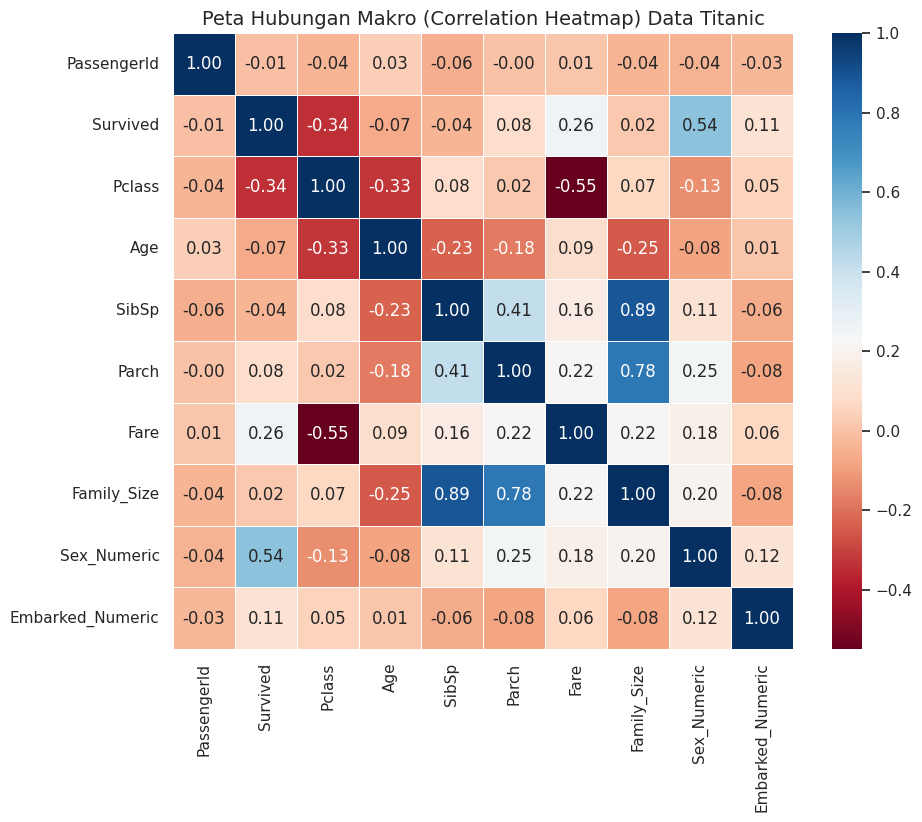

In [24]:
# Melihat peta korelasi makro
# 1. Isolasi hanya kolom yang berisi angka
kolom_numerik = df.select_dtypes(include=['number'])

# 2. Hitung koefisien korelasi matematisnya
matriks_korelasi = kolom_numerik.corr()

# 3. Visualisasikan menggunakan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Peta Hubungan Makro (Correlation Heatmap) Data Titanic', fontsize=14)
plt.show()

# Insight:

# 🏠 TAKE-HOME MISSION: Final Review (Menggabungkan Semua Jurus)
Misi ini akan me-review Pandas (Hari 1) dan Visualisasi (Hari 2) sekaligus!

**Skenario:** Bos Anda meminta laporan khusus mengenai anak-anak di kapal Titanic.

**Instruksi Misi:**
1. **Filtering:** Buat variabel `df_anak` yang HANYA berisi penumpang berumur di bawah 16 tahun (`< 16`).
2. **Visualisasi Univariate:** Dari `df_anak` tersebut, buat `sns.countplot` untuk melihat ada berapa banyak anak laki-laki dan anak perempuan.
3. **Visualisasi Bivariate:** Buat `sns.barplot` untuk melihat peluang keselamatan (`Survived`) anak-anak tersebut berdasarkan Kelas Tiketnya (`Pclass`).
4. Berikan komentar kesimpulan dari 2 grafik tersebut!

/tmp/ipykernel_527/4137200592.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df_anak, palette='Set1')


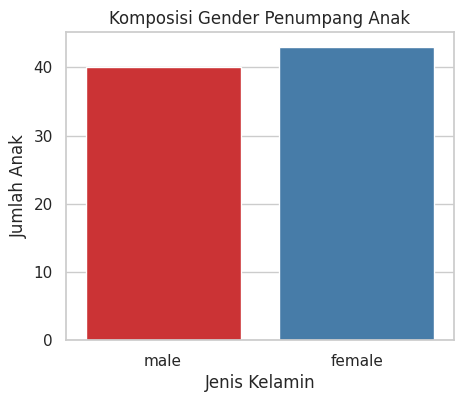

/tmp/ipykernel_527/4137200592.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_anak, palette='summer', errorbar=None)


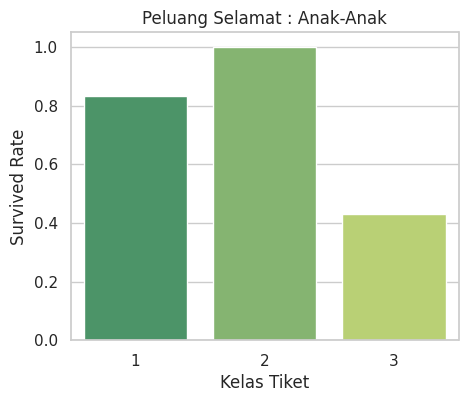

"\n1) Memfilter dataset umur menjadi umur dibawah dibawah 16 tahun, di definisikan menjadi variable 'Anak'\n2) Dari hasil analisis grafik countplot tersebut, jumlah penumpang anak laki-laki dan perempuan hampir sama\n3) Dari hasil analisis grafik barplot tersebut, kelas tiket memiliki hubungan negatif dengan peluang selamat penumpang anak artinya kelas tiket yang lebih tinggi/mahal cenderung memiliki peluang selamat yang lebih baik dari kelas yang lebih rendah.\n\n"

In [40]:
# =====================================================================
# KERJAKAN TAKE-HOME MISSION ANDA DI BAWAH INI
# =====================================================================

# 1. Filtering Data Anak
# KETIK DI SINI:
df_anak = df[df['Age'] < 16]
df_anak.sample(3) #mengecek apakah field baru 'Anak' sudah ada

print("========" * 12)
print("========" * 12)

# 2. Countplot (Jumlah Anak Laki vs Perempuan)
# KETIK DI SINI:
plt.figure(figsize=(5,4))
sns.countplot(x='Sex', data=df_anak, palette='Set1')
plt.title("Komposisi Gender Penumpang Anak", fontsize=12)
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Anak")
plt.show()

print("========" * 12)
print("========" * 12)

# 3. Barplot (Keselamatan Anak berdasarkan Kelas Tiket)
# KETIK DI SINI:
plt.figure(figsize=(5,4))
sns.barplot(x='Pclass', y='Survived', data=df_anak, palette='summer', errorbar=None)
plt.title('Peluang Selamat : Anak-Anak', fontsize=12)
plt.xlabel('Kelas Tiket')
plt.ylabel('Survived Rate')
plt.show()

print("========" * 12)
print("========" * 12)


# 4. TULIS KESIMPULAN AKHIR LAPORANMU:
"""
1) Memfilter dataset umur menjadi umur dibawah dibawah 16 tahun, di definisikan menjadi variable 'Anak'
2) Dari hasil analisis grafik countplot tersebut, jumlah penumpang anak laki-laki dan perempuan hampir sama
3) Dari hasil analisis grafik barplot tersebut, kelas tiket memiliki hubungan negatif dengan peluang selamat penumpang anak artinya kelas tiket yang lebih tinggi/mahal cenderung memiliki peluang selamat yang lebih baik dari kelas yang lebih rendah.

"""

---
### 🎓 Akhir dari Hari ke-2: Eksplorasi Data Selesai!

Selamat! Anda baru saja mempraktikkan alur kerja (*SOP*) asli dari seorang Data Scientist di perusahaan teknologi. Anda sudah bisa membersihkan data yang cacat, dan membuat grafik untuk membuktikan fakta historis.

**Sumber Belajar Mandiri (Wajib Simpan!):**
* 🎨 **Seaborn Gallery:** [seaborn.pydata.org](https://seaborn.pydata.org/examples/index.html) (Contekan berbagai jenis grafik yang indah dan langsung bisa di-copy paste kodenya).
* 📊 **Python Graph Gallery:** [python-graph-gallery.com](https://python-graph-gallery.com/) (Panduan memilih grafik yang benar beserta contoh visualisasinya).

*Besok di **Hari ke-3**, kita akan menggunakan data yang sudah bersih ini untuk menciptakan Otak Kecerdasan Buatan (Machine Learning) pertama kita!* 🚀